# BoC Rate Decisions — 3-Way Direction Prediction Experiment

This notebook runs the full predictor lineup on the discrete BoC task:
**a probability distribution over {cut, hold, hike} at the next fixed
announcement date, issued four weeks (28 days) before the announcement**,
scored with the **Ranked Probability Score (RPS)**. Read
`01_boc_data_exploration.ipynb` first for the problem framing, data layer,
and cutoff-discipline walkthrough. A compact **binary warm-up** (*cut vs no
cut*, Brier-scored) opens the experiment as a copy-paste reference for
naturally binary problems — prediction-market-style questions — before the
3-way main event.

**Why a 28-day lead.** On the eve of a decision, the 2-year GoC yield has
already absorbed the market consensus and the outcome is priced to
near-certainty — a T−1 "forecast" mostly reads market expectations off a
curve. Four weeks out, the decision is genuinely uncertain, so the skill
being measured is *anticipation*. The eve-of-decision variant is kept as a
diagnostic, and a dedicated section compares the two leads directly.

**The leakage problem, discrete edition.** Frontier LLMs were trained on
data that includes news coverage of every historical BoC decision. For
backtest origins in 2010–2024, an LLM-based predictor may simply *remember*
what the Bank decided — and unlike the continuous use cases, here
memorisation is worth even more, because a single recalled label (cut /
hold / hike) is the entire answer. Backtest RPS for LLMP and the agent is
therefore an **upper bound on live skill**, useful for verifying the
pipeline and calibration format, not for claiming forecasting ability. The
conventional predictors (climatology, multinomial logistic) are blind to
the future by construction, so their backtest scores are honest.

The protected 2025–2026 eval window at the end is closer to (and partly
beyond) current model training cutoffs — that comparison is fairer, and the
budget-gated `evaluate()` harness keeps it honest.

**What's here:**

1. Setup and experiment config — smoke (3 origins) vs full (120 origins).
2. Spec — loaded from YAML; ordered `categories` + explicit `origin_dates`.
3. Binary warm-up — the compact Brier-scored reference, and the
   RPS(K=2) ≡ Brier identity.
4. Predictors — climatology, multinomial logistic, categorical LLMP,
   agentic analyst.
5. Backtest — cached on disk; RPS leaderboard with skill scores.
6. Skill vs lead time — the canonical T−28 forecast against the T−1
   eve-of-decision diagnostic.
7. Predicted distributions over time, by method.
8. Decision panels — context, predictions, rationales, and the realised
   outcome per meeting.
9. Protected eval — budget-gated 2025–2026 window.

---
## 1. Setup

The analytical code lives in modules alongside this notebook:

- `data.py` — registers the target rate, derived decision series, and covariates.
- `predictors/` — the (multinomial) logistic baseline and the BoC LLMP recipes.
- `analyst_agent/` — the agentic BoC analyst (prompt builder + configs).
- `analysis.py` / `plots.py` — score leaderboard, calibration, timeline.

**Five specs, two jobs.** There is one *pedagogical backtest* on the deep
pre-2025 history (where the cutoff-safe baselines shine and the LLM/agent rows
are an honest-to-goodness *upper bound* — they may be reciting memorised
decisions) and one *honest eval* on the scarce post-cutoff window (the only
place the LLM/agent scores reflect forecasting). The binary warm-up and the
eve-of-decision spec are small single-purpose illustrations.

| Spec file | Role | Lead | Origins | Window | Cutoff posture |
|---|---|---|---|---|---|
| `boc_rate_direction_smoke.yaml` | fast dev loop (a slice of the full backtest) | T−28 | 3 | 2024 | pedagogical |
| `boc_rate_direction_backtest.yaml` | **canonical backtest** (3 easing + 3 tightening cycles) | T−28 | 120 | 2010–2024 | pedagogical / LLM upper-bound |
| `boc_rate_direction_eval.yaml` | **protected eval — the honest scoreboard** (`max_runs: 5`) | T−28 | 12 | 2025–Jun 2026 | post-cutoff / honest |
| `boc_rate_cut_smoke.yaml` | binary reference for the §3 warm-up (Brier-scored) | T−1 | 3 | 2024 | illustrative |
| `boc_rate_direction_eve_smoke.yaml` | eve-of-decision diagnostic for the §7 lead comparison | T−1 | 3 | 2024 | illustrative |

`EXPERIMENT_CONFIG` (next code cell) swaps the main backtest between the 3-origin
smoke slice and the 120-origin full window; the warm-up and eve specs are always
the small ones. A use-case test (`test_specs.py`) asserts every origin list stays
consistent with `meeting_schedule.yaml` at each spec's own lead.

Populate the data cache once before running:

```bash
uv run python scripts/fetch_boc.py
```

In [1]:
from __future__ import annotations

import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv
from IPython.display import Markdown, display  # noqa: A004


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env", override=False)

from aieng.forecasting.evaluation import BacktestSpec, cached_backtest, describe_spec
from boc_rate_decisions.analysis import (
    decision_panel_data,
    panel_rationales_markdown,
    predictions_to_frame,
    score_leaderboard,
)
from boc_rate_decisions.data import (
    DIRECTION_SERIES_ID,
    RATE_CUT_EVENT_SERIES_ID,
    TARGET_RATE_SERIES_ID,
    build_boc_service,
)
from boc_rate_decisions.plots import plot_decision_panel, plot_probability_timeline


STATCAN_CACHE = ROOT / "data" / "statcan"
FRED_CACHE = ROOT / "data" / "fred"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
SPECS_DIR = ROOT / "implementations" / "boc_rate_decisions" / "specs"

svc = build_boc_service(statcan_cache_dir=STATCAN_CACHE, fred_cache_dir=FRED_CACHE)

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
direction_df = svc.get_series(DIRECTION_SERIES_ID, as_of=_as_of)
event_df = svc.get_series(RATE_CUT_EVENT_SERIES_ID, as_of=_as_of)
rate_df = svc.get_series(TARGET_RATE_SERIES_ID, as_of=_as_of)  # daily target rate, for panel context
n_cuts = int((direction_df["value"] == -1.0).sum())
n_holds = int((direction_df["value"] == 0.0).sum())
n_hikes = int((direction_df["value"] == 1.0).sum())
print(f"Direction series: {len(direction_df)} resolved meetings — {n_cuts} cuts, {n_holds} holds, {n_hikes} hikes")

Direction series: 141 resolved meetings — 15 cuts, 108 holds, 18 hikes


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# EXPERIMENT_CONFIG sets the size of the *main* direction backtest (sections 5-9):
#
#   "smoke"  3 origins — a slice of the full backtest (one hold, two cuts in 2024)
#            fast dev loop: ~3 LLM calls per LLM-based predictor
#   "full"   120 origins, 2010-2024 — the canonical pre-2025 backtest
#            first LLM-based run makes 120 calls per predictor before caching
#
# The binary warm-up (§3) and the eve-of-decision diagnostic (§7) are always the
# small single-purpose specs — they illustrate a format and a lead-time point,
# so a 120-origin variant would add cost without adding clarity. The honest
# post-2025 scoreboard is the separate protected eval in §10.

EXPERIMENT_CONFIG = "smoke"

_BACKTEST_SPEC_FILES = {
    "smoke": "boc_rate_direction_smoke.yaml",
    "full": "boc_rate_direction_backtest.yaml",
}
_BACKTEST_SPEC_FILE = _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]
# Cache key for artefacts under data/predictions/<spec_id>/<predictor_id>.yaml
BACKTEST_SPEC_ID = f"boc_rate_direction_{EXPERIMENT_CONFIG}"

# The binary warm-up (§3) and eve diagnostic (§7) each use a single fast spec.
_WARMUP_SPEC_FILE = "boc_rate_cut_smoke.yaml"
WARMUP_SPEC_ID = "boc_rate_cut_smoke"
_EVE_SPEC_FILE = "boc_rate_direction_eve_smoke.yaml"
EVE_SPEC_ID = "boc_rate_direction_eve_smoke"

print(f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILE}")
print(f"  warm-up: {_WARMUP_SPEC_FILE}   eve diagnostic: {_EVE_SPEC_FILE}")

Config: 'smoke'  →  boc_rate_direction_smoke.yaml
  warm-up: boc_rate_cut_smoke.yaml   eve diagnostic: boc_rate_direction_eve_smoke.yaml


---
## 2. The backtest spec

Three things distinguish this spec from the continuous use cases:

- **`payload_type: categorical`** on the task — predictors must return a
  `CategoricalForecast(probabilities={...})` and the harness scores with
  RPS instead of CRPS.
- **`categories`** — the task declares the *ordered* outcome set and the
  mapping to series values: `cut(−1) < hold(0) < hike(+1)`. The order is
  what makes RPS distance-sensitive: mass on `hike` when the Bank cuts is
  penalised through *two* cumulative thresholds, mass on `hold` through one.
- **`origin_dates`** — BoC meetings are an irregular calendar (eight per
  year, unevenly spaced), so the spec lists every forecast origin explicitly
  (`announcement_date − 28 days`) instead of deriving origins from a stride.
  Scheduled meetings are never closer than 35 days apart, so the previous
  decision is always visible at the origin.

In [3]:
with (SPECS_DIR / _BACKTEST_SPEC_FILE).open() as f:
    backtest_spec = BacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))

BacktestSpec
  description: Three-origin smoke backtest for local and CI testing of the BoC rate-direction pipeline. Same task and warmup as boc_rate_direction_backtest, restricted to one hold and two cut meetings in 2024, with origins 28 days before each announcement.
  start:       2024-03-01 00:00:00
  end:         2024-09-30 00:00:00
  stride:      1
  warmup:      8
  origins:     3 explicit dates (irregular calendar)

Task: boc_rate_direction_next_meeting
  description: At the Bank of Canada fixed announcement date occurring 28 days after the forecast origin, will the Bank CUT, HOLD, or HIKE its target for the overnight rate? Outcome is the direction of the target-rate change at that announcement (any size). Announcements are at 09:45 ET; the forecast must be issued with information available four weeks before the announcement, before markets have converged on the decision.
  horizons:    28
  frequency:   D
  payload:     categorical
  categories:  cut(-1) < hold(0) < hike(1)
  

---
## 3. Warm-up: the binary special case (a copy-paste reference)

Many real prediction problems are naturally binary — *will X happen by
date D?* — and prediction markets trade exactly that contract. Before the
3-way main event, this section runs the same machinery on the binary view
of the problem (*cut vs no cut*, `payload_type: binary`, Brier-scored) so
you have a minimal, complete reference to copy for your own binary tasks:

- the task: `specs/boc_rate_cut_smoke.yaml`,
- the floor baseline: `HistoricalFrequencyPredictor` (the constant base rate),
- the LLMP recipe: `build_llmp_binary` wrapping
  `BinaryProbabilityLLMPredictor`,
- the conventional model: the same `BoCLogisticPredictor`, which dispatches
  to plain logistic regression on binary tasks.

The binary reference stays at the **T−1 (eve-of-decision) lead**: its job is
to demonstrate the payload and scoring format in the fewest moving parts,
not the lead-time question — that analysis belongs to the 3-way experiment
below.

**Why the two framings agree.** The unnormalized RPS over \(K\) ordered
categories is a sum of \(K-1\) cumulative binary Brier scores, so for
\(K = 2\) it *is* the Brier score \((p - y)^2\). (Brier's original 1950
multi-category score is twice this — both conventions appear in the
literature; this codebase uses the cumulative form everywhere.) The cell
below verifies the identity numerically with `compute_rps` and
`compute_brier_score` — the binary problem is the \(K{=}2\) corner of the
categorical machinery, which is exactly why the 3-way framing is the more
general reference.

In [4]:
from aieng.forecasting.evaluation import compute_brier_score, compute_rps
from aieng.forecasting.methods import HistoricalFrequencyPredictor
from boc_rate_decisions.predictors import BoCLogisticPredictor, build_llmp_binary


# RPS(K=2) == Brier identity: categories ordered [no-cut, cut].
for p_cut, outcome in [(0.1, 0), (0.3, 1), (0.85, 1)]:
    rps = compute_rps([[1.0 - p_cut, p_cut]], [outcome])
    brier = compute_brier_score([p_cut], [float(outcome)])
    print(f"P(cut)={p_cut:.2f}, outcome={outcome}:  RPS(K=2) = {rps:.4f}  ==  Brier = {brier:.4f}")

# The compact binary experiment: floor baseline + logistic + LLMP, Brier-scored.
with (SPECS_DIR / _WARMUP_SPEC_FILE).open() as f:
    warmup_spec = BacktestSpec.model_validate(yaml.safe_load(f))

warmup_predictors = [HistoricalFrequencyPredictor(), BoCLogisticPredictor(), build_llmp_binary()]
warmup_results = {}
for predictor in warmup_predictors:
    warmup_results[predictor.predictor_id] = cached_backtest(
        predictor=predictor, spec=warmup_spec, spec_id=WARMUP_SPEC_ID, data_service=svc, store_dir=PREDICTIONS_DIR
    )

print()
print(score_leaderboard(warmup_results, reference_id="historical_frequency").to_string(index=False))

P(cut)=0.10, outcome=0:  RPS(K=2) = 0.0100  ==  Brier = 0.0100
P(cut)=0.30, outcome=1:  RPS(K=2) = 0.4900  ==  Brier = 0.4900
P(cut)=0.85, outcome=1:  RPS(K=2) = 0.0225  ==  Brier = 0.0225

                                                               predictor_id metric  mean_score  n_predictions  n_skipped_origins  skill_vs_reference
llmp_binary_probability_boc_cut_v1_rprovider[gemini-3.1-flash-lite-preview]  brier    0.249167              3                  0              0.5808
                                                         boc_logistic_macro  brier    0.303607              3                  0              0.4893
                                                       historical_frequency  brier    0.594444              3                  0              0.0000


---
## 4. Predictors

Seven predictors spanning the methodology spectrum, all implementing the same
`Predictor` API:

| Group | Predictor | What it sees | Notes |
|---|---|---|---|
| Floor baseline | `CategoricalFrequencyPredictor` | Past outcomes only | Constant climatological distribution; the bar every other predictor must clear |
| Conventional (legacy) | `BoCLogisticPredictor(include_gdp=False)` | Leak-safe macro features | Multinomial logistic regression fit at every origin: yield spread, rate momentum, inflation gap, unemployment momentum |
| Conventional (+GDP) | `BoCLogisticPredictor(include_gdp=True)` | Legacy features + real GDP YoY growth | Same fitting procedure, expanded covariate set; this notebook measures the incremental impact of GDP directly |
| LLMP | `CategoricalProbabilityLLMPredictor` | Outcome history + prompt context | Direct distribution elicitation in one structured call; no tools, no covariates |
| Agentic (legacy) | `AgentPredictor` + `BoCDecisionPromptBuilder(include_gdp=False)` | Rate path + outcome history + legacy macro snapshot | Baseline BoC analyst agent variant |
| Agentic (+GDP) | `AgentPredictor` + `BoCDecisionPromptBuilder(include_gdp=True)` | Legacy agent snapshot + GDP YoY growth | Measures whether GDP helps LLM reasoning under the same prompt contract |

The notebook now mirrors the GDP feature toggle in both conventional and
agentic families, so deltas are directly comparable (`+GDP` minus legacy)
within each model class.

In [5]:
import importlib

from aieng.forecasting.methods import CategoricalFrequencyPredictor
from boc_rate_decisions.predictors import build_llmp_direction
import boc_rate_decisions.analyst_agent.agent as _boc_agent_mod
import boc_rate_decisions.analyst_agent as _boc_agent_pkg

# If this notebook stays open across code edits, reload to avoid stale function signatures.
importlib.reload(_boc_agent_mod)
importlib.reload(_boc_agent_pkg)
from boc_rate_decisions.analyst_agent import build_boc_agent_predictor, build_boc_basic_config


# Model for the LLM-based predictors (LLMP + agent). Flash-lite is the fast/cheap
# default so a first Run All stays light; gemini-3.5-flash reasons noticeably
# better at higher cost/latency. Switch by commenting the two lines below.
MODEL = "gemini-3.1-flash-lite-preview"  # fast/cheap default
# MODEL = "gemini-3.5-flash"             # stronger reasoning, higher cost/slower

climatology = CategoricalFrequencyPredictor()
logistic = BoCLogisticPredictor(include_gdp=False, predictor_id="boc_logistic_macro")
logistic_gdp = BoCLogisticPredictor(include_gdp=True, predictor_id="boc_logistic_macro_gdp")
llmp = build_llmp_direction(model=MODEL, reasoning_effort=None)
agent = build_boc_agent_predictor(
    build_boc_basic_config(model=MODEL, include_gdp=False),
    include_gdp=False,
)
agent_gdp = build_boc_agent_predictor(
    build_boc_basic_config(model=MODEL, include_gdp=True),
    include_gdp=True,
)

# News-grounded agent variant (web search with temporal cutoffs). Leakage
# risk is higher on historical dates; enable deliberately, not by default.
# from boc_rate_decisions.analyst_agent import build_boc_news_config
# agent_news = build_boc_agent_predictor(build_boc_news_config(model=MODEL), include_gdp=False)
# agent_news_gdp = build_boc_agent_predictor(build_boc_news_config(model=MODEL, include_gdp=True), include_gdp=True)

all_predictors = [climatology, logistic, logistic_gdp, llmp, agent, agent_gdp]

PREDICTOR_COLORS: dict[str, str] = {
    climatology.predictor_id: "#7f7f7f",
    logistic.predictor_id: "#1f77b4",
    logistic_gdp.predictor_id: "#17becf",
    llmp.predictor_id: "#d62728",
    agent.predictor_id: "#ff7f0e",
    agent_gdp.predictor_id: "#bcbd22",
}
PREDICTOR_LABELS: dict[str, str] = {
    climatology.predictor_id: "Climatology",
    logistic.predictor_id: "Multinomial logistic",
    logistic_gdp.predictor_id: "Multinomial logistic (+GDP)",
    llmp.predictor_id: "LLMP direction",
    agent.predictor_id: "Agent (basic)",
    agent_gdp.predictor_id: "Agent (basic, +GDP)",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

  categorical_frequency
  boc_logistic_macro
  boc_logistic_macro_gdp
  llmp_categorical_probability_boc_direction_v1_rprovider[gemini-3.1-flash-lite-preview]
  agent_predictor_boc_analyst_basic_gemini-3.1-flash-lite-preview_categorical
  agent_predictor_boc_analyst_basic_gdp_gemini-3.1-flash-lite-preview_categorical


---
## 5. Backtest (cached on disk)

`cached_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>.yaml` and reuses it on subsequent
runs; pass `force_refresh=True` to recompute. The climatology and logistic
predictors are free; the LLMP and agent make one LLM call per origin on a
first run (3 calls under `smoke`, 120 under `full`).

**Reading the scores.** RPS accumulates squared error over the cumulative
distribution. A confident, correct forecast scores near 0; a confident
forecast on the *adjacent* category costs ~1; a confident forecast on the
*opposite tail* (hike when the Bank cuts) costs ~2 — the ordering is what
separates RPS from a plain multi-class Brier. Mean RPS over the window
rewards predictors that keep mass on hold through the long quiet stretches
*and* shift it toward the right tail in time for cycle turns — four weeks
before each announcement, while the outcome is still genuinely open.
Remember the asymmetry from the intro — only the climatology and logistic
rows of the leaderboard are leakage-free.

In [6]:
from aieng.forecasting.evaluation.backtest import BacktestResult


results: dict[str, BacktestResult] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results[predictor.predictor_id] = cached_backtest(
        predictor=predictor,
        spec=backtest_spec,
        spec_id=BACKTEST_SPEC_ID,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
        force_refresh=True,
    )
    r = results[predictor.predictor_id]
    print(f"  mean RPS = {r.mean_score:.4f}  ({len(r.predictions)} predictions, {r.skipped_origins} skipped)")

Running categorical_frequency ...
  mean RPS = 0.6158  (3 predictions, 0 skipped)
Running boc_logistic_macro ...
  mean RPS = 0.3680  (3 predictions, 0 skipped)
Running boc_logistic_macro_gdp ...
  mean RPS = 0.3621  (3 predictions, 0 skipped)
Running llmp_categorical_probability_boc_direction_v1_rprovider[gemini-3.1-flash-lite-preview] ...
  mean RPS = 0.2083  (3 predictions, 0 skipped)
Running agent_predictor_boc_analyst_basic_gemini-3.1-flash-lite-preview_categorical ...
  mean RPS = 0.0750  (3 predictions, 0 skipped)
Running agent_predictor_boc_analyst_basic_gdp_gemini-3.1-flash-lite-preview_categorical ...
  mean RPS = 0.0900  (3 predictions, 0 skipped)


---
## 6. RPS leaderboard

`skill_vs_reference` is the skill score against the
`CategoricalFrequencyPredictor`: positive = beats the climatology, 0 =
matches it, negative = worse than knowing nothing. With holds at ~76%, the
climatological forecast is a deceptively low bar that conditions-blind
models struggle to clear — most of the score separation happens at the
handful of cycle-turn meetings.

> ⚠️ **Leakage caveat — read before comparing.** Gemini's training cutoff is ~January 2025, so on this **pre-2025 backtest** the LLM-Process and agent rows may be *reciting memorised rate decisions* rather than forecasting. Treat their scores as an **upper bound**, not live skill — the cutoff-safe baselines (climatology, logistic) are the honest comparison here. A fair LLM evaluation needs **post-cutoff / prospective** origins (see §10's budget-gated eval and the energy reference).

> **The honest LLM/agent comparison is the post-2025 protected eval in §10**, which now runs by default — the 2010–24 leaderboard here is pedagogical (rich history for the cutoff-safe baselines; an upper bound for the LLM rows).

In [7]:
board = score_leaderboard(results, reference_id=climatology.predictor_id)
board["label"] = board["predictor_id"].map(PREDICTOR_LABELS)
print(board.set_index("label").drop(columns="predictor_id").to_string())

predictions_df = predictions_to_frame(results, direction_df)
print(f"\nTidy prediction rows: {len(predictions_df)}")
print(predictions_df[["predictor_id", "meeting_date", "p_cut", "p_hold", "p_hike", "outcome_label", "score"]].head())

                            metric  mean_score  n_predictions  n_skipped_origins  skill_vs_reference
label                                                                                               
Agent (basic)                  rps    0.075000              3                  0              0.8782
Agent (basic, +GDP)            rps    0.090033              3                  0              0.8538
LLMP direction                 rps    0.208333              3                  0              0.6617
Multinomial logistic (+GDP)    rps    0.362099              3                  0              0.4119
Multinomial logistic           rps    0.368007              3                  0              0.4023
Climatology                    rps    0.615751              3                  0              0.0000

Tidy prediction rows: 18
            predictor_id meeting_date     p_cut    p_hold    p_hike  \
0  categorical_frequency   2024-04-10  0.049180  0.803279  0.147541   
1  categorical_frequency

### GDP delta check (conventional model only)

This is the direct Day-2 question: does adding GDP change the conventional
model's predictions materially?

The next cell compares:

- mean RPS for the legacy logistic vs the GDP-augmented logistic,
- per-meeting probability deltas (`+GDP` minus legacy),
- and the meetings where those distribution shifts are largest.

In [8]:
legacy_id = logistic.predictor_id
gdp_id = logistic_gdp.predictor_id

legacy_rps = board.loc[board["predictor_id"] == legacy_id, "mean_score"].iloc[0]
gdp_rps = board.loc[board["predictor_id"] == gdp_id, "mean_score"].iloc[0]

print("Conventional-model RPS comparison")
print(f"  {PREDICTOR_LABELS[legacy_id]:28s}: {legacy_rps:.6f}")
print(f"  {PREDICTOR_LABELS[gdp_id]:28s}: {gdp_rps:.6f}")
print(f"  delta (+GDP - legacy):           {gdp_rps - legacy_rps:+.6f}")

conv = predictions_df[predictions_df["predictor_id"].isin([legacy_id, gdp_id])].copy()
wide = conv.pivot_table(
    index="meeting_date",
    columns="predictor_id",
    values=["p_cut", "p_hold", "p_hike", "score"],
)

for prob in ["p_cut", "p_hold", "p_hike", "score"]:
    wide[(prob, "delta")]= wide[(prob, gdp_id)] - wide[(prob, legacy_id)]

summary = wide[[
    ("score", legacy_id),
    ("score", gdp_id),
    ("score", "delta"),
    ("p_cut", "delta"),
    ("p_hold", "delta"),
    ("p_hike", "delta"),
]].copy()
summary.columns = [
    "rps_legacy",
    "rps_plus_gdp",
    "rps_delta",
    "p_cut_delta",
    "p_hold_delta",
    "p_hike_delta",
]

print("\nLargest absolute distribution shifts (top 10 meetings)")
summary["max_abs_prob_shift"] = summary[["p_cut_delta", "p_hold_delta", "p_hike_delta"]].abs().max(axis=1)
print(summary.sort_values("max_abs_prob_shift", ascending=False).head(10).to_string())

Conventional-model RPS comparison
  Multinomial logistic        : 0.368007
  Multinomial logistic (+GDP) : 0.362099
  delta (+GDP - legacy):           -0.005908

Largest absolute distribution shifts (top 10 meetings)
              rps_legacy  rps_plus_gdp  rps_delta  p_cut_delta  p_hold_delta  p_hike_delta  max_abs_prob_shift
meeting_date                                                                                                  
2024-09-04      0.171067      0.153443  -0.017624     0.021884     -0.021982      0.000098            0.021982
2024-04-10      0.001873      0.001949   0.000076     0.000880     -0.000956      0.000076            0.000956
2024-06-05      0.931082      0.930904  -0.000178     0.000101     -0.000823      0.000723            0.000823


### Interpreting the GDP delta result

> **What is RPS?**

> **RPS (Ranked Probability Score)** is a proper scoring rule for ordered categorical forecasts (here: cut, hold, hike).
- It compares the forecast cumulative distribution to the realised outcome's cumulative distribution.
- Lower is better: $0$ is perfect, larger values are worse.
- It rewards calibrated probabilities and penalises mass placed far from the true category.

> **Final verdict on the new GDP covariate (this run):**
- Legacy logistic mean RPS: **0.3680**
- Logistic + GDP mean RPS: **0.3621**
- Delta (`+GDP - legacy`): **-0.0059** (improvement, since lower is better)

> GDP provides a **small but real** improvement in aggregate score for the conventional model, with the largest single-meeting probability shift around **2.2 percentage points**. The effect is helpful but not transformative.

### GDP delta check (agent model)

Same question for the BoC analyst agent: does exposing GDP in the leak-safe
macro snapshot change predictions/scores materially?

The next cell compares:

- mean RPS for the legacy agent vs the GDP-augmented agent,
- per-meeting probability deltas (`+GDP` minus legacy),
- and top meetings by absolute distribution shift.

Interpretation uses the same rule as above: lower RPS is better.

In [9]:
agent_legacy_id = agent.predictor_id
agent_gdp_id = agent_gdp.predictor_id

agent_legacy_rps = board.loc[board["predictor_id"] == agent_legacy_id, "mean_score"].iloc[0]
agent_gdp_rps = board.loc[board["predictor_id"] == agent_gdp_id, "mean_score"].iloc[0]
agent_delta = agent_gdp_rps - agent_legacy_rps

print("Agent-model RPS comparison")
print(f"  {PREDICTOR_LABELS[agent_legacy_id]:28s}: {agent_legacy_rps:.6f}")
print(f"  {PREDICTOR_LABELS[agent_gdp_id]:28s}: {agent_gdp_rps:.6f}")
print(f"  delta (+GDP - legacy):           {agent_delta:+.6f}")

agent_conv = predictions_df[predictions_df["predictor_id"].isin([agent_legacy_id, agent_gdp_id])].copy()
agent_wide = agent_conv.pivot_table(
    index="meeting_date",
    columns="predictor_id",
    values=["p_cut", "p_hold", "p_hike", "score"],
)

for prob in ["p_cut", "p_hold", "p_hike", "score"]:
    agent_wide[(prob, "delta")] = agent_wide[(prob, agent_gdp_id)] - agent_wide[(prob, agent_legacy_id)]

agent_summary = agent_wide[[
    ("score", agent_legacy_id),
    ("score", agent_gdp_id),
    ("score", "delta"),
    ("p_cut", "delta"),
    ("p_hold", "delta"),
    ("p_hike", "delta"),
]].copy()
agent_summary.columns = [
    "rps_legacy",
    "rps_plus_gdp",
    "rps_delta",
    "p_cut_delta",
    "p_hold_delta",
    "p_hike_delta",
]

print("\nLargest absolute distribution shifts (top 10 meetings)")
agent_summary["max_abs_prob_shift"] = agent_summary[["p_cut_delta", "p_hold_delta", "p_hike_delta"]].abs().max(axis=1)
print(agent_summary.sort_values("max_abs_prob_shift", ascending=False).head(10).to_string())

if agent_delta < 0:
    verdict = "improvement"
elif agent_delta > 0:
    verdict = "worse"
else:
    verdict = "no change"

print(f"\nAgent GDP verdict (this run): {verdict} (lower RPS is better).")

Agent-model RPS comparison
  Agent (basic)               : 0.075000
  Agent (basic, +GDP)         : 0.090033
  delta (+GDP - legacy):           +0.015033

Largest absolute distribution shifts (top 10 meetings)
              rps_legacy  rps_plus_gdp  rps_delta  p_cut_delta  p_hold_delta  p_hike_delta  max_abs_prob_shift
meeting_date                                                                                                  
2024-09-04        0.0625        0.1250     0.0625        -0.10          0.05          0.05                0.10
2024-04-10        0.0400        0.0226    -0.0174        -0.05          0.04          0.01                0.05
2024-06-05        0.1225        0.1225     0.0000         0.00          0.00          0.00                0.00

Agent GDP verdict (this run): worse (lower RPS is better).


### Interpreting the agent GDP delta result

The interpretation logic is the same as for the conventional model: **lower mean RPS is better**.

- Legacy agent mean RPS: **0.0750**
- Agent + GDP mean RPS: **0.0900**
- Delta (`+GDP - legacy`): **+0.0150** (**worse**, since lower is better)

In this run, adding GDP **degrades** the agent's aggregate score rather than improving it.
The effect is material relative to the prior tiny lift and should be treated as a negative result for the current setup.
A reasonable next step is to inspect meeting-level shifts in `agent_summary` to see whether the deterioration is broad-based or concentrated in a few dates.

---
## 7. Skill vs lead time: T−28 vs the eve of the decision

The same meetings, the same predictors, two information states: the
canonical four-week lead and the eve-of-decision (T−1) diagnostic
(`boc_rate_direction_eve_smoke.yaml`). Three things to expect:

- **Climatology is lead-invariant** — it conditions on nothing, so its RPS
  is identical at both leads. It anchors the comparison.
- **Conditioning predictors should improve toward T−1** as the market
  converges: the yield spread is far more decisive the day before a
  decision than four weeks out. The *gap* between a predictor's T−28 and
  T−1 scores is roughly "how much of its skill is anticipation vs reading
  the market's final answer".
- **For the LLM-based rows, interpret with the leakage caveat** — on
  historical origins a memorised outcome inflates both leads equally, which
  itself is diagnostic: a genuine forecaster should get *worse* as the lead
  grows; a memoriser won't.

In [10]:
with (SPECS_DIR / _EVE_SPEC_FILE).open() as f:
    eve_spec = BacktestSpec.model_validate(yaml.safe_load(f))

eve_results: dict[str, BacktestResult] = {}
for predictor in all_predictors:
    eve_results[predictor.predictor_id] = cached_backtest(
        predictor=predictor,
        spec=eve_spec,
        spec_id=EVE_SPEC_ID,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )

lead_comparison = score_leaderboard(results)[["predictor_id", "mean_score"]].rename(columns={"mean_score": "rps_t28"})
eve_board = score_leaderboard(eve_results)[["predictor_id", "mean_score"]].rename(columns={"mean_score": "rps_t1"})
lead_comparison = lead_comparison.merge(eve_board, on="predictor_id")
lead_comparison["anticipation_gap"] = (lead_comparison["rps_t28"] - lead_comparison["rps_t1"]).round(4)
lead_comparison["label"] = lead_comparison["predictor_id"].map(PREDICTOR_LABELS)
print(lead_comparison.set_index("label").drop(columns="predictor_id").to_string())
print()
print("anticipation_gap = RPS(T-28) - RPS(T-1): how much score the predictor")
print("recovers as the market converges. ~0 for climatology by construction.")

                              rps_t28    rps_t1  anticipation_gap
label                                                            
Agent (basic)                0.075000  0.016733            0.0583
Agent (basic, +GDP)          0.090033  0.016667            0.0734
LLMP direction               0.208333  0.157500            0.0508
Multinomial logistic (+GDP)  0.362099  0.300011            0.0621
Multinomial logistic         0.368007  0.306900            0.0611
Climatology                  0.615751  0.615751            0.0000

anticipation_gap = RPS(T-28) - RPS(T-1): how much score the predictor
recovers as the market converges. ~0 for climatology by construction.


---
## 8. Predicted distributions over time, by method

One stacked-area panel per method. Within a panel the three category
probabilities **sum to 1 at every meeting**, so the bands show how each method
moves probability mass between cut (red), hold (grey), and hike (teal) across
the backtest. The marker strip along the top of each panel is the **realised**
outcome at every meeting — filled and colour-coded when resolved, hollow when
it hasn't resolved yet.

Read each panel as: *does the method shift mass onto the right band, and in
time?* Climatology is essentially flat by construction (the bar to clear); a
good conditional method visibly tilts toward the cut/hike bands as cycle turns
approach, while the outcome strip tells you whether that tilt was right.

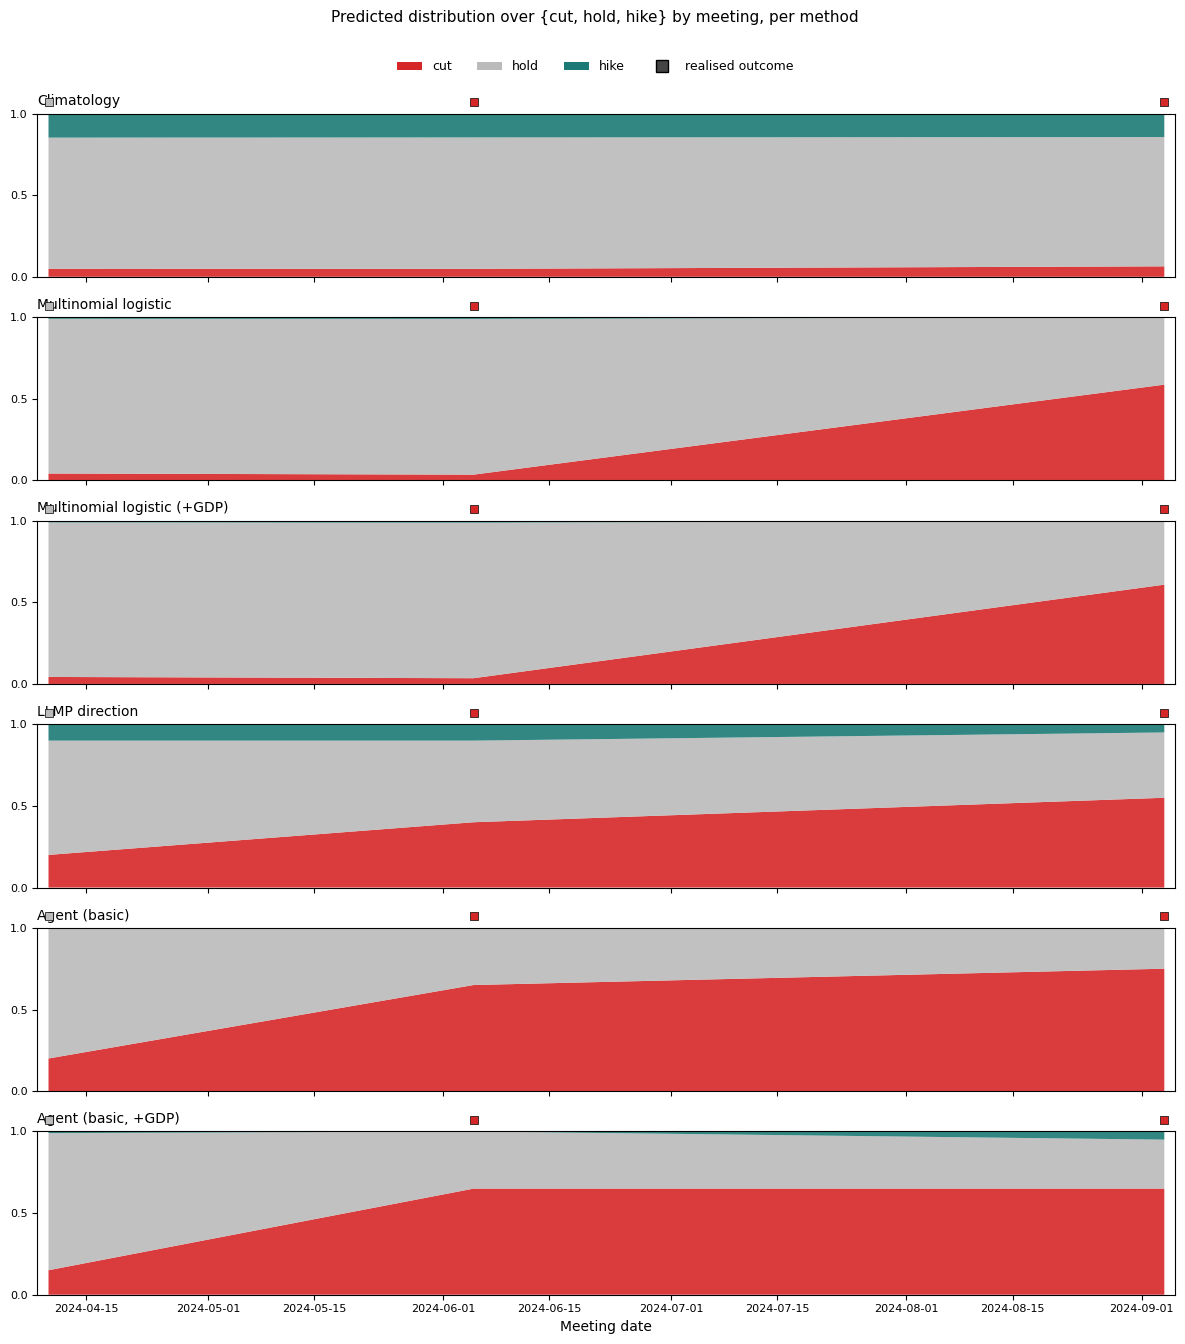

In [11]:
fig, _ = plot_probability_timeline(predictions_df, labels=PREDICTOR_LABELS)
plt.show()

---
## 9. Decision panels: prediction vs. outcome

The leaderboard compresses each forecast to a single number. A **decision
panel** unpacks one meeting so you can see what every method actually said and
why:

- **Context strip** — the policy-rate path over the year leading into the
  meeting (dotted line = forecast origin, solid coloured line = the
  announcement), plus the rate at origin and the prior decision.
- **Probability bars** — each method's predicted cut/hold/hike distribution.
  The **★** marks the category that actually happened, and the bar for the
  realised outcome is outlined. Each row also shows that method's RPS.
- **Rationales** — rendered as markdown beneath the figure (for the methods
  that produce one: the agent and the LLMP), so the reasoning stays readable.

We show the most recent meeting first; `show_meeting(...)` below re-renders the
panel for any other announcement and its rationales.

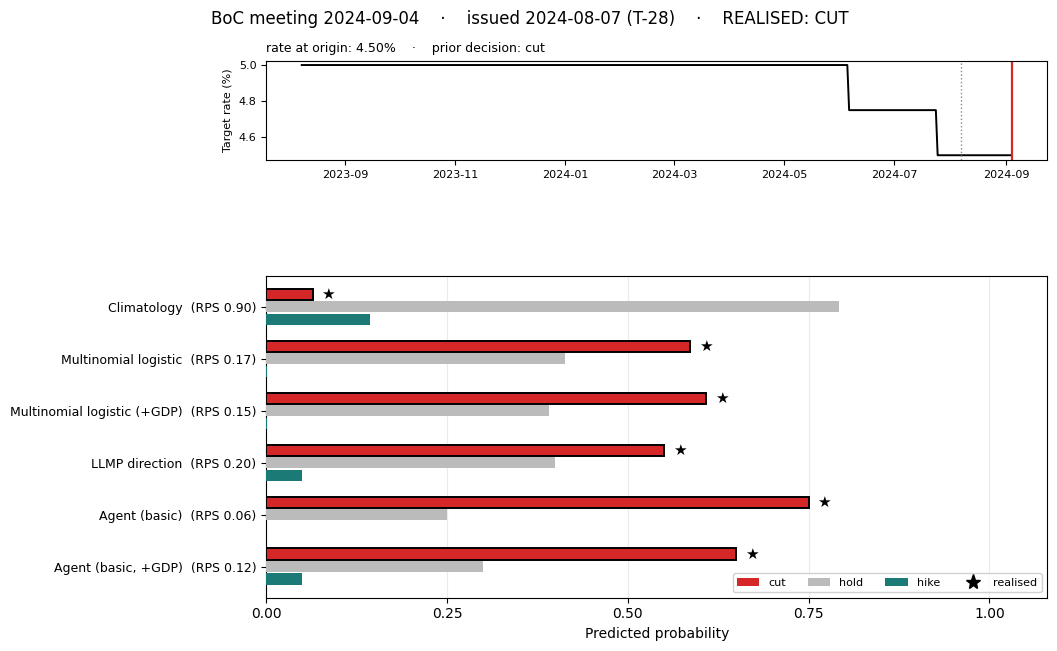

**LLMP direction**

The Bank of Canada recently initiated an easing cycle with back-to-back cuts in June and July 2024. Historical patterns show that when the Bank begins an adjustment cycle, they frequently follow through with additional moves in the same direction, especially when inflation pressures are cooling. While 'hold' remains the most common action in the long-term base rate, the momentum established in the previous two meetings makes another cut the most likely path to bring the policy rate toward a more neutral stance as inflation approaches the target range.

---

**Agent (basic)**

Key signals: Consecutive rate cuts in June and July 2024 (easing cycle established), Deeply inverted yield curve (spread of -1.23%), Positive unemployment momentum indicating economic slack, Inflation gap narrowing towards the 2% target

The Bank of Canada has clearly initiated an easing cycle, having cut rates at the previous two consecutive meetings (June and July 2024). The macro indicators support continuing this trajectory: the yield curve is significantly inverted (2-year yield ~123 bps below the policy rate), signalling the bond market's strong expectation of further easing. Inflation remains close to the 2% target (inflation gap ~0.67%), and rising unemployment momentum provides the central bank with sufficient 'slack' justification to proceed with further cuts to prevent the restrictive policy stance from overtightening the economy. Given the recent pattern of consecutive cuts, the Bank is unlikely to stop now unless forced by a major shock, making a 'cut' the most probable outcome.

---

**Agent (basic, +GDP)**

Key signals: Consecutive cuts in June and July 2024 established an easing cycle, Negative yield spread (-1.23) indicating market expectation of lower rates, Rising unemployment momentum (1.0) providing space for easing, Inflation cooling toward the 2% target

The Bank of Canada has initiated an easing cycle with back-to-back 25bps cuts in June and July 2024. The macro environment supports further easing: the negative yield spread (-1.23) indicates market expectation of continued policy loosening, and the positive unemployment momentum (1.0) suggests slack is building in the labour market. While inflation remains above the 2% target, the trend is moving toward the target, allowing the Bank to continue recalibrating rates lower to support economic activity. Given the Bank's typical approach of sequential, data-dependent moves once a cycle has begun, another cut is the most probable outcome for the September 4 announcement.

In [12]:
# Most recent meeting in the backtest, all methods at a glance.
panel = decision_panel_data(results, direction_df)
fig, _ = plot_decision_panel(panel, rate_df, labels=PREDICTOR_LABELS)
plt.show()

rationale_md = panel_rationales_markdown(panel, PREDICTOR_LABELS)
if rationale_md:
    display(Markdown(rationale_md))

### Viewing other meetings

`show_meeting(date)` re-renders the panel for any announcement and prints the
full (untruncated) rationales and key signals beneath it.

These rationale fields are also the seam for the planned **reasoning-alignment**
evaluation: the Bank publishes its own explanation with every decision, so an
LLM judge could later score whether a method was right *for the right reasons*
— most valuable exactly where the backtest score is least trustworthy
(historical origins with training-data leakage).

Available meetings: 2024-04-10, 2024-06-05, 2024-09-04


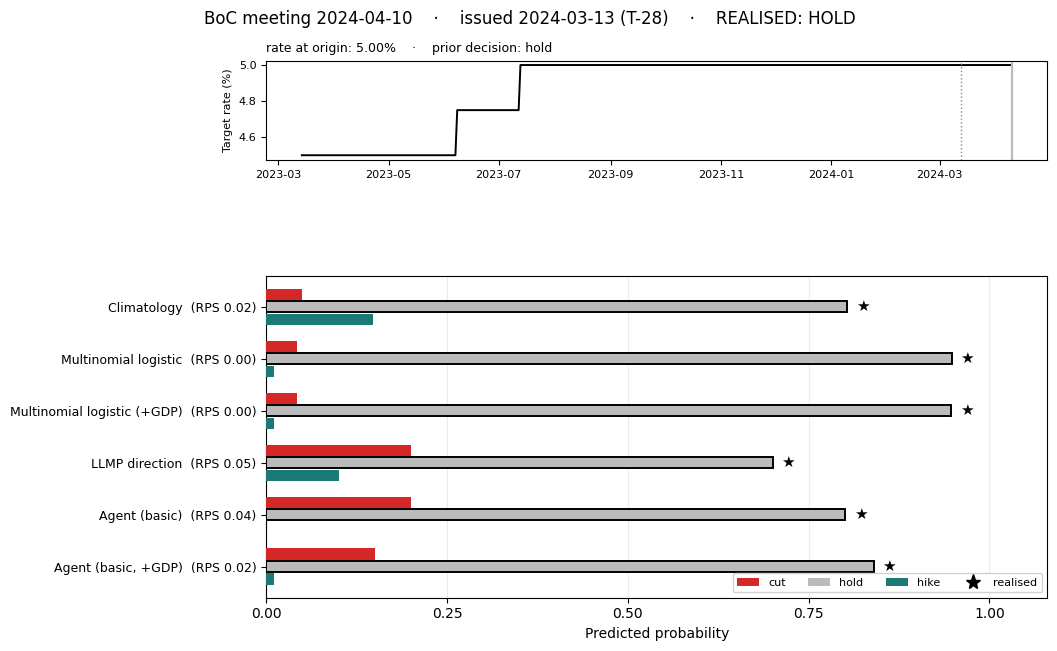

**LLMP direction**

Historically, the Bank of Canada maintains a 'hold' for the vast majority of its meetings, even within broader policy cycles. Given the prevailing economic environment in early 2024, characterized by sticky inflation and the Bank's cautious approach to normalizing interest rates, a pause ('hold') remains the most probable outcome. While market chatter regarding potential cuts has increased, the central bank has remained committed to data dependency, favoring a 'hold' until they gain greater confidence that inflation is sustainably trending toward the 2% target.

---

**Agent (basic)**

Key signals: Continued policy rate 'hold' pattern since July 2023, Negative yield spread (-0.89) indicating market expectation of future cuts, Inflation above target (0.86%) but trending lower, Bank of Canada's historical preference for gradualism and data-dependent pauses

The Bank of Canada is currently in a 'holding' phase, having maintained the policy rate at 5.0% for several consecutive meetings (since July 2023). While inflation remains above the 2% target (inflation_gap = 0.86), it is trending towards the target, and the Bank has clearly signaled a transition to considering when to begin cutting rates rather than raising them further. The negative yield spread (-0.90) strongly indicates that the bond market is pricing in future cuts, reflecting expectations of an economic slowdown. Given the Bank's typical institutional behavior—a high degree of data dependence and gradualism—they are unlikely to pivot to a cut as early as April without more definitive evidence of sustained disinflation and further labor market softening. A hold is the highest probability outcome, as they will likely wait for more data confirmation before starting the easing cycle.

---

**Agent (basic, +GDP)**

Key signals: Continued 'hold' decision history since July 2023, Negative 2-year yield spread (-0.9%) signalling market expectation for cuts, Inflation gap is moderating but remains above target, Rising unemployment momentum indicating softening labour market

As of March 13, 2024, the Bank of Canada has maintained the overnight rate at 5.0% for five consecutive meetings. While inflation remains above the 2% target, the inflation gap is moderating, and unemployment momentum is showing signs of slack. The significant negative yield spread (-0.9%) indicates that the bond market is strongly pricing in future rate cuts, reflecting anticipation that the restrictive stance is beginning to weigh on economic growth. However, the Bank remains data-dependent and cautious; they require more confidence that inflation is sustainably returning to the target before initiating an easing cycle. A move to cut in April is possible but less likely than a continued hold, as the Governing Council likely wants to see further cooling in domestic price pressures before moving.

In [13]:
def show_meeting(meeting_date: str) -> None:
    """Render a meeting's decision panel, then its rationales as markdown."""
    panel = decision_panel_data(results, direction_df, meeting_date=meeting_date)
    fig, _ = plot_decision_panel(panel, rate_df, labels=PREDICTOR_LABELS)
    plt.show()
    rationale_md = panel_rationales_markdown(panel, PREDICTOR_LABELS)
    if rationale_md:
        display(Markdown(rationale_md))


available_meetings = sorted({str(d.date()) for d in predictions_df["meeting_date"].unique()})
print("Available meetings:", ", ".join(available_meetings))

# Inspect any meeting by date, e.g. the first origin in the window:
show_meeting(available_meetings[0])

---
## 10. The honest scoreboard — protected post-2025 eval

**This is the result that counts for the LLM/agent rows.** `specs/boc_rate_direction_eval.yaml`
covers the 12 announcements from January 2025 through June 2026 at the canonical
28-day lead: the tail of the easing cycle (cuts in Jan, Mar, Sep, Oct 2025)
followed by an extended hold at 2.25%. These origins are **at/after the model's
~January 2025 training cutoff**, so — unlike the 2010–24 backtest above — the
LLM-Process and agent scores here reflect *forecasting*, not recall. (The window
contains no hikes, so it can't reward hike discrimination, but RPS still penalises
mass wasted on the hike tail.)

It runs by default and **unbudgeted** (`tracker=None`) so you always see the
scoreboard. The spec carries `max_runs: 5`; in a real competition you'd pass an
`EvalTracker` to enforce that budget across sessions — the scarcity is the point:
an eval you can re-run freely becomes another backtest to over-fit.

In [14]:
from aieng.forecasting.evaluation import EvalSpec, evaluate


# The post-2025 protected eval is the honest scoreboard for the LLM/agent rows, so
# it runs by default. We run it UNBUDGETED here (tracker=None) so the result always
# shows. In a real competition you'd enforce the spec's max_runs budget across
# sessions — an eval you can re-run freely becomes another backtest to over-fit:
#     from aieng.forecasting.evaluation import EvalTracker
#     tracker = EvalTracker(ROOT / "data" / "eval_runs.yaml")  # then pass tracker=tracker below
with (SPECS_DIR / "boc_rate_direction_eval.yaml").open() as f:
    eval_spec = EvalSpec.model_validate(yaml.safe_load(f))

eval_results = {}
for predictor in all_predictors:
    print(f"Evaluating {predictor.predictor_id} on the post-2025 window ...", flush=True)
    eval_results[predictor.predictor_id] = evaluate(predictor=predictor, spec=eval_spec, data_service=svc, tracker=None)
    r = eval_results[predictor.predictor_id]
    print(f"  {PREDICTOR_LABELS[predictor.predictor_id]:20s} mean RPS = {r.mean_score:.4f}")

eval_board = score_leaderboard(eval_results, reference_id=climatology.predictor_id)
print()
print(eval_board.to_string(index=False))

Evaluating categorical_frequency on the post-2025 window ...
  Climatology          mean RPS = 0.2985
Evaluating boc_logistic_macro on the post-2025 window ...
  Multinomial logistic mean RPS = 0.1858
Evaluating boc_logistic_macro_gdp on the post-2025 window ...
  Multinomial logistic (+GDP) mean RPS = 0.1792
Evaluating llmp_categorical_probability_boc_direction_v1_rprovider[gemini-3.1-flash-lite-preview] on the post-2025 window ...
  LLMP direction       mean RPS = 0.2312
Evaluating agent_predictor_boc_analyst_basic_gemini-3.1-flash-lite-preview_categorical on the post-2025 window ...
  Agent (basic)        mean RPS = 0.1921
Evaluating agent_predictor_boc_analyst_basic_gdp_gemini-3.1-flash-lite-preview_categorical on the post-2025 window ...
  Agent (basic, +GDP)  mean RPS = 0.2219

                                                                          predictor_id metric  mean_score  n_predictions  n_skipped_origins  skill_vs_reference
                                             

---
## 11. What's next — the deferred components

This notebook completes the **quantitative** version of the problem. Three
components are deliberately deferred, and the code leaves explicit seams for
each:

1. **BoC communications as context.** Every decision comes with a press
   release, and four per year come with a full Monetary Policy Report. The
   `CategoricalProbabilityLLMPredictorConfig.user_prompt_suffix` hook and the
   `build_boc_news_config` retrieval sub-agent are the insertion points for
   report-grounded variants once the document ingestion work (Track 2)
   lands. The key engineering constraint carries over unchanged: documents
   must be filtered by `released_at`, exactly like series data.

2. **Reasoning-alignment evaluation.** Both the agent and the LLMP now emit a
   `rationale` per meeting (shown in the decision panels in section 9). An LLM
   evaluator comparing that rationale against the Bank's own published
   explanation would complement the RPS with a *process* metric — was the
   predictor right for the right reasons? This matters most precisely where
   the score is least trustworthy (historical origins with leakage).

3. **Live forecasting.** The cleanest evaluation needs no leakage analysis
   at all: forecast the *next* announcement before it happens. The eval spec
   ends at June 2026; extending `meeting_schedule.yaml` with the Bank's
   published 2027 calendar and issuing forecasts the day before each
   announcement turns this use case into a standing live experiment — eight
   genuinely out-of-sample data points per year.